In [1]:
import networks
from networks import LateralInhibitoryLayer
import generators
from generators import MultipleSpeedCrossingBarZeroMean, EllipticGaussianGenerator
import numpy as np
import matplotlib.pyplot as plt


def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# 2D Gaussian

In [ ]:
#create stimuli generator
vg_params = EllipticGaussianGenerator.default_params()
vg_params['mean'] = [0, 0]
vg = generators.EllipticGaussianGenerator(vg_params)

#create a linear network with 2 units and change the w_rule rule accordingly (hebbian, bcm_abs, perceptron)
network_params = LateralInhibitoryLayer.default_hparams(vg.get_shape())
network_params['activation'] = 'linear'
network_params['num_units_y'] = 2
network_params['gradient'] = 'direct'
network_params['w_update'] = 'perceptron'
network_params['w_rectify'] = False
network_params['w_seed'] = 42
network_params['w_init'] = 'random_normal'
network_params['w_lr'] = 0.0001
network_params['m_update'] = 'hebbian'
network_params['m_rectify'] = False
network_params['m_init'] = 'identity'
network_params['m_lr'] = 0.0001
network_params['num_steps'] = 100
network_params['step'] = 0.01
#network_params['normalize_w_weights'] = True

network = LateralInhibitoryLayer(network_params)

4.022840513243406
Eigenvalues: [0.25421268 4.01480033]
$\sqrt{\sum_i(1-\lambda_i^{-1})^2}$: 3.028293492064515


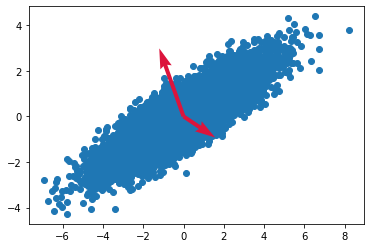

In [12]:
#plot example data with network weight vectors
data = []
for i in range(15000):
    vg.set_random_position()
    x = vg.get_current_frame()
    data.append(x.copy())

inverse_m = np.linalg.inv(network.m)
neural_filters = network.w
plt.scatter(np.array(data)[:, 0], np.array(data)[:, 1])

plt.quiver(
    0, 0, neural_filters[0,0], neural_filters[0,1],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)

plt.quiver(
    0, 0, neural_filters[1,0], neural_filters[1,1],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)
cov_x = np.cov(np.array(data), rowvar=False)
print(np.linalg.norm(cov_x, ord='fro'))
eigenvalues = np.linalg.eigvalsh(cov_x)
covariance_distance = np.sqrt(np.sum((1.0 - 1.0 / eigenvalues) ** 2))

print("Eigenvalues:", eigenvalues)
print(r"$\sqrt{\sum_i(1-\lambda_i^{-1})^2}$:", covariance_distance)

In [10]:
#save results
distance_from_identity = []
consistency_error = []
second_moment_estimate = []
mse_error = []
synaptic_input_distance_from_identity = []

Iteration 0
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG!
CAREFUL INPUT IS NEGATIVE! RUNNING MEAN WILL BE WRONG

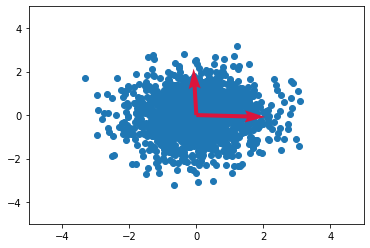

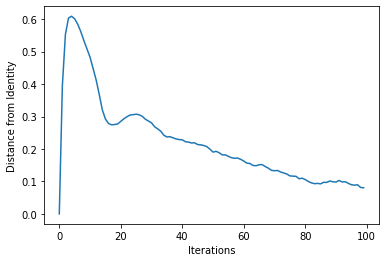

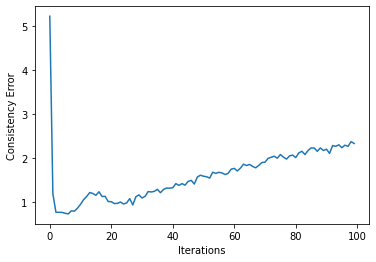

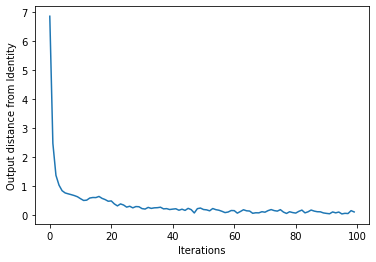

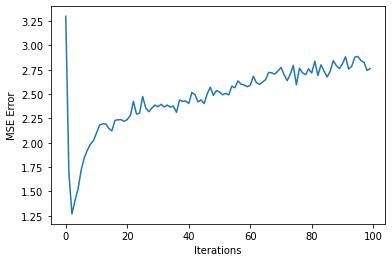

In [11]:
#train network and save
for i in range(100000):
    if i % 1000 == 0:
        print(f"Iteration {i}")
        examples = []
        examples_input = []
        errors = []
        for j in range(1000):
            vg.set_random_position()
            x = vg.get_current_frame()
            network.reset_network()
            network.update_activations(x, False)
            examples.append(network.y.copy())
            errors.append(np.linalg.norm(x.reshape(-1, 1).T[0] - network.projection(), ord=2))
            examples_input.append(network.w @ x.reshape(-1, 1).T[0])
        synaptic_input_distance_from_identity.append(np.linalg.norm(np.cov(np.array(examples_input), rowvar=False) - np.eye(network.m.shape[0]), ord='fro'))
        current_second_moment_estimate = np.cov(np.array(examples), rowvar=False)
        distance_from_identity.append(np.linalg.norm(network.m - np.eye(network.m.shape[0]), ord='fro'))
        consistency_error.append(np.linalg.norm((network.w @ network.w.T) - (current_second_moment_estimate), ord='fro'))
        second_moment_estimate.append(np.linalg.norm(current_second_moment_estimate - np.eye(network.m.shape[0]), ord='fro'))
        mse_error.append(np.mean(errors))
        
    vg.set_random_position()
    x = vg.get_current_frame()
    network.reset_network()
    network.update_activations(x, False)
    network.update_parameters(['m', 'w'])
    
activity = []
for i in range(1500):
    vg.set_random_position()
    x = vg.get_current_frame()
    network.reset_network()
    network.update_activations(x, False) 
    activity.append(network.y.copy())

plt.scatter(np.array(activity)[:, 0], np.array(activity)[:, 1])
inverse_m = np.linalg.inv(network.m)
plt.quiver(
    0, 0, inverse_m[0,0], inverse_m[1,0],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)

plt.quiver(
    0, 0, inverse_m[0,1], inverse_m[1,1],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.show()

plt.plot(distance_from_identity)
plt.xlabel('Iterations')
plt.ylabel('Distance from Identity')
plt.show()

plt.plot(consistency_error)
plt.xlabel('Iterations')
plt.ylabel('Consistency Error')
plt.show()

plt.plot(second_moment_estimate)
plt.xlabel('Iterations')
plt.ylabel('Output distance from Identity')
plt.show()

plt.plot(mse_error)
plt.xlabel('Iterations')
plt.ylabel('MSE Error')
plt.show()



# Crossbar

In [8]:
#create stimuli generator
vg_params = MultipleSpeedCrossingBarZeroMean.default_params()
vg = generators.MultipleSpeedCrossingBarZeroMean(vg_params)
print(vg.get_shape())
#create a linear network with 50 units and change the w_rule rule accordingly (hebbian, bcm_abs, perceptron)
network_params = LateralInhibitoryLayer.default_hparams(vg.get_shape())
network_params['activation'] = 'linear'
network_params['num_units_y'] = 50
network_params['gradient'] = 'direct'
network_params['w_update'] = 'hebbian'
network_params['w_rectify'] = False
network_params['w_seed'] = 42
network_params['w_init'] = 'random_normal'
network_params['w_lr'] = 0.0001
network_params['m_update'] = 'hebbian'
network_params['m_rectify'] = False
network_params['m_init'] = 'identity'
network_params['m_lr'] = 0.0001
network_params['num_steps'] = 100
network_params['step'] = 0.01
#network_params['normalize_w_weights'] = True

network = LateralInhibitoryLayer(network_params)
#save results
distance_from_identity = []
consistency_error = []
second_moment_estimate = []
mse_error = []
synaptic_input_distance_from_identity = []

(12, 12, 1)


Iteration 0
Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000
Iteration 5000
Iteration 6000
Iteration 7000
Iteration 8000
Iteration 9000
Iteration 10000
Iteration 11000
Iteration 12000
Iteration 13000
Iteration 14000
Iteration 15000
Iteration 16000
Iteration 17000
Iteration 18000
Iteration 19000
Iteration 20000
Iteration 21000
Iteration 22000
Iteration 23000
Iteration 24000
Iteration 25000
Iteration 26000
Iteration 27000
Iteration 28000
Iteration 29000
Iteration 30000
Iteration 31000
Iteration 32000
Iteration 33000
Iteration 34000
Iteration 35000
Iteration 36000
Iteration 37000
Iteration 38000
Iteration 39000
Iteration 40000
Iteration 41000
Iteration 42000
Iteration 43000
Iteration 44000
Iteration 45000
Iteration 46000
Iteration 47000
Iteration 48000
Iteration 49000
Iteration 50000
Iteration 51000
Iteration 52000
Iteration 53000
Iteration 54000
Iteration 55000
Iteration 56000
Iteration 57000
Iteration 58000
Iteration 59000
Iteration 60000
Iteration 61000
Iteration 62000
Itera

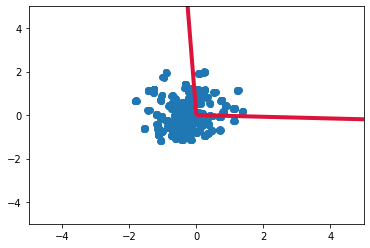

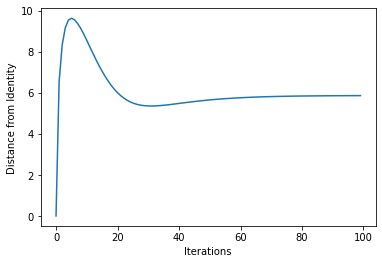

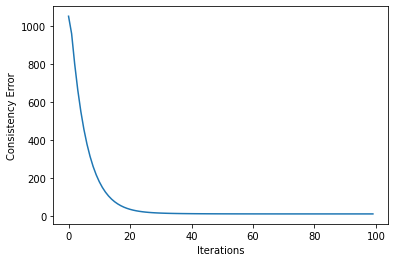

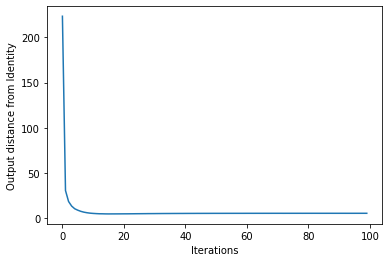

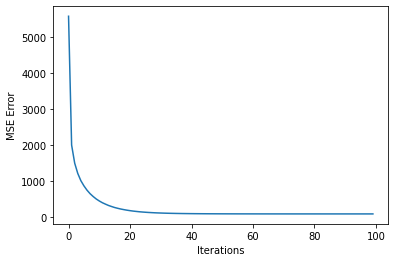

In [9]:
#network.lr_w = 0.0005
#network.lr_m = 0.001
for i in range(100000):
    if i % 1000 == 0:
        print(f"Iteration {i}")
        examples = []
        examples_input = []
        errors = []
        for j in range(1000):
            vg.set_random_position()
            x = vg.get_current_frame().flatten()
            network.reset_network()
            network.update_activations(x, False)
            examples.append(network.y.copy())
            errors.append(np.linalg.norm((x - network.projection()).reshape(1,-1), ord=2))
            examples_input.append(network.w @ x)
        synaptic_input_distance_from_identity.append(np.linalg.norm(np.cov(np.array(examples_input), rowvar=False) - np.eye(network.m.shape[0]), ord='fro'))
        current_second_moment_estimate = np.cov(np.array(examples), rowvar=False)
        distance_from_identity.append(np.linalg.norm(network.m - np.eye(network.m.shape[0]), ord='fro'))
        consistency_error.append(np.linalg.norm((network.w @ network.w.T) - (current_second_moment_estimate), ord='fro'))
        second_moment_estimate.append(np.linalg.norm(current_second_moment_estimate - np.eye(network.m.shape[0]), ord='fro'))
        mse_error.append(np.mean(errors))
        
    vg.set_random_position()
    x = vg.get_current_frame().flatten()
    network.reset_network()
    network.update_activations(x, False)
    network.update_parameters(['m', 'w'])
    
activity = []
for i in range(1500):
    vg.set_random_position()
    x = vg.get_current_frame().flatten()
    network.reset_network()
    network.update_activations(x, False) 
    activity.append(network.y.copy())

plt.scatter(np.array(activity)[:, 0], np.array(activity)[:, 1])
inverse_m = np.linalg.inv(network.m)
plt.quiver(
    0, 0, inverse_m[0,0], inverse_m[1,0],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)

plt.quiver(
    0, 0, inverse_m[0,1], inverse_m[1,1],                       # Starting point (0,0) and vector components (u, v)
    angles='xy', scale_units='xy', scale=0.5,  # Keeps vector scaling 1:1 with plot axes
    color='crimson', width=0.012,
)
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.show()

plt.plot(distance_from_identity)
plt.xlabel('Iterations')
plt.ylabel('Distance from Identity')
plt.show()

plt.plot(consistency_error)
plt.xlabel('Iterations')
plt.ylabel('Consistency Error')
plt.show()

plt.plot(second_moment_estimate)
plt.xlabel('Iterations')
plt.ylabel('Output distance from Identity')
plt.show()

plt.plot(mse_error)
plt.xlabel('Iterations')
plt.ylabel('MSE Error')
plt.show()



In [4]:
distance_from_identity_perceptron = distance_from_identity
consistency_error_perceptron = consistency_error
second_moment_estimate_perceptron = second_moment_estimate
mse_error_perceptron = mse_error

In [7]:
distance_from_identity_oja = distance_from_identity
consistency_error_oja = consistency_error
second_moment_estimate_oja = second_moment_estimate
mse_error_oja = mse_error

In [10]:
distance_from_identity_hebbian = distance_from_identity
consistency_error_hebbian = consistency_error
second_moment_estimate_hebbian = second_moment_estimate
mse_error_hebbian = mse_error

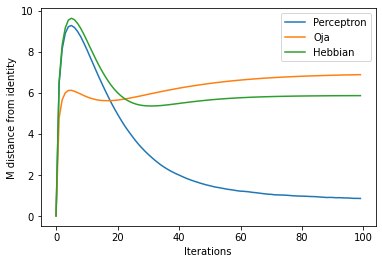

In [15]:
plt.plot(distance_from_identity_perceptron, label='Perceptron')
plt.plot(distance_from_identity_oja, label='Oja')
plt.plot(distance_from_identity_hebbian, label='Hebbian')
plt.xlabel('Iterations')
plt.ylabel('M distance from identity')
plt.legend()
plt.show()

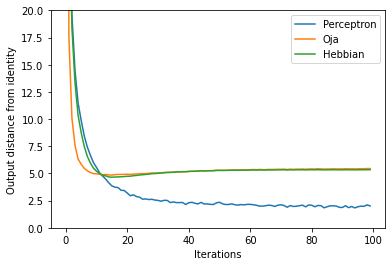

In [17]:
plt.plot(second_moment_estimate_perceptron, label='Perceptron')
plt.plot(second_moment_estimate_oja, label='Oja')
plt.plot(second_moment_estimate_hebbian, label='Hebbian')
plt.xlabel('Iterations')
plt.ylabel('Output distance from identity')
plt.ylim(0, 20)
plt.legend()
plt.show()